In [1]:
# DELAYED CLINICAL DECISION_MAKING INVESTIGATION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Load config paths
BASE_DIR = Path.cwd().parent

RAW_DATA_DIR = BASE_DIR / "data" / "raw"

ED_VISITS_FILE = RAW_DATA_DIR / "ed_visits.csv"

print("Current notebook location:", Path.cwd())
print("Project root:", BASE_DIR)
print("ED file exists:", ED_VISITS_FILE.exists())
print("ED path:", ED_VISITS_FILE)

Current notebook location: c:\Users\lapto\OneDrive\Predictive Healthcare\Health-Care-predictive-Analysis\notebooks
Project root: c:\Users\lapto\OneDrive\Predictive Healthcare\Health-Care-predictive-Analysis
ED file exists: True
ED path: c:\Users\lapto\OneDrive\Predictive Healthcare\Health-Care-predictive-Analysis\data\raw\ed_visits.csv


In [3]:
# Load data

ed = pd.read_csv(ED_VISITS_FILE)

print("ED visits:", ed.shape)
display(ed.head())

ED visits: (6000, 22)


,ed_visit_id,patient_id,arrival_datetime,departure_datetime,triage_level,triage_category,chief_complaint,day_of_week,hour_of_arrival,month,...,door_to_doctor_min,ed_los_minutes,imaging_ordered,labs_ordered,iv_access,disposition,admitted_from_ed,left_ama,attending_ed_md,hospital
0,ED-0000001,PAT-004656,2022-11-07 00:00,2022-11-07 09:21,3,Urgent,Drug overdose,Monday,0,11,...,172,561,0,1,1,Admitted,0,0,ED-MD-10,MHN Boston General
1,ED-0000002,PAT-004065,2024-06-23 00:00,2024-06-23 02:45,1,Resuscitation,Leg swelling,Sunday,0,6,...,28,165,1,0,0,Discharged Home,1,0,ED-MD-40,MHN Boston General
2,ED-0000003,PAT-003922,2020-12-07 00:00,2020-12-07 06:25,5,Non-Urgent,Hypertensive urgency,Monday,0,12,...,11,385,0,1,0,Discharged Home,1,0,ED-MD-33,MHN Roxbury Community
3,ED-0000004,PAT-001788,2020-12-14 00:00,2020-12-14 04:07,4,Less Urgent,Leg swelling,Monday,0,12,...,5,247,0,0,1,Discharged Home,0,0,ED-MD-36,MHN Boston General
4,ED-0000005,PAT-004741,2021-08-19 00:00,2021-08-19 01:35,3,Urgent,Altered mental status,Thursday,0,8,...,65,95,0,1,1,Admitted,0,0,ED-MD-25,MHN Jamaica Plain


In [4]:
# Inspect dataset

print("\nColumns:")
print(ed.columns.tolist())

print("\nMissing values:")
print(ed.isna().sum())

print("\nBasic statistics:")
display(ed.describe())


Columns:
['ed_visit_id', 'patient_id', 'arrival_datetime', 'departure_datetime', 'triage_level', 'triage_category', 'chief_complaint', 'day_of_week', 'hour_of_arrival', 'month', 'season', 'wait_time_minutes', 'door_to_doctor_min', 'ed_los_minutes', 'imaging_ordered', 'labs_ordered', 'iv_access', 'disposition', 'admitted_from_ed', 'left_ama', 'attending_ed_md', 'hospital']

Missing values:
ed_visit_id           0
patient_id            0
arrival_datetime      0
departure_datetime    0
triage_level          0
triage_category       0
chief_complaint       0
day_of_week           0
hour_of_arrival       0
month                 0
season                0
wait_time_minutes     0
door_to_doctor_min    0
ed_los_minutes        0
imaging_ordered       0
labs_ordered          0
iv_access             0
disposition           0
admitted_from_ed      0
left_ama              0
attending_ed_md       0
hospital              0
dtype: int64

Basic statistics:


,triage_level,hour_of_arrival,month,wait_time_minutes,door_to_doctor_min,ed_los_minutes,imaging_ordered,labs_ordered,iv_access,admitted_from_ed,left_ama
count,6000.000000,6000.0,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3.041333,0.0,6.513167,68.526000,68.771667,308.642000,0.496667,0.321833,0.500000,0.274167,0.045500
std,1.003224,0.0,3.463740,77.299654,77.091107,125.070451,0.500031,0.467218,0.500042,0.446131,0.208415
min,1.000000,0.0,1.000000,0.000000,5.000000,35.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.0,3.000000,18.000000,18.000000,223.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,0.0,7.000000,44.000000,44.000000,302.000000,0.000000,0.000000,0.500000,0.000000,0.000000
75%,4.000000,0.0,10.000000,91.250000,91.250000,382.250000,1.000000,1.000000,1.000000,1.000000,0.000000
max,5.000000,0.0,12.000000,1132.000000,1132.000000,1412.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
# Convert dates
ed["arrival_datetime"] = pd.to_datetime(ed["arrival_datetime"], errors="coerce")

In [10]:
# Create delayed decision column
ed["delayed_decision"] = (
    ed["door_to_doctor_min"] > 30
).astype(int)

In [11]:
delay_by_day = ed.groupby("day_of_week").agg(
    total_visits=("ed_visit_id", "count"),
    avg_wait_time=("wait_time_minutes", "mean"),
    avg_door_to_doctor=("door_to_doctor_min", "mean"),
    delay_rate=("delayed_decision", "mean")
).reset_index()

delay_by_day["avg_wait_time"] = delay_by_day["avg_wait_time"].round(1)
delay_by_day["avg_door_to_doctor"] = delay_by_day["avg_door_to_doctor"].round(1)
delay_by_day["delay_rate"] = (delay_by_day["delay_rate"] * 100).round(1)

display(delay_by_day)

,day_of_week,total_visits,avg_wait_time,avg_door_to_doctor,delay_rate
0,Friday,857,69.0,69.3,62.1
1,Monday,814,71.3,71.5,63.9
2,Saturday,877,65.8,66.1,61.3
3,Sunday,853,65.6,65.8,58.4
4,Thursday,910,65.2,65.5,61.2
5,Tuesday,834,71.5,71.7,62.1
6,Wednesday,855,71.7,71.9,63.3


In [13]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

delay_by_day["day_of_week"] = pd.Categorical(
    delay_by_day["day_of_week"],
    categories=day_order,
    ordered=True
)

delay_by_day = delay_by_day.sort_values("day_of_week")

display(delay_by_day)

,day_of_week,total_visits,avg_wait_time,avg_door_to_doctor,delay_rate
1,Monday,814,71.3,71.5,63.9
5,Tuesday,834,71.5,71.7,62.1
6,Wednesday,855,71.7,71.9,63.3
4,Thursday,910,65.2,65.5,61.2
0,Friday,857,69.0,69.3,62.1
2,Saturday,877,65.8,66.1,61.3
3,Sunday,853,65.6,65.8,58.4


In [14]:
# Create delay indicators

# A delayed decision can be based on long wait time,
# long door-to-doctor time, or long total ED length of stay.
ed["delayed_decision"] = (
    (ed["wait_time_minutes"] > 120) |
    (ed["door_to_doctor_min"] > 90) |
    (ed["ed_los_minutes"] > 360)
).astype(int)

print("\nDelayed clinical decision distribution:")
print(ed["delayed_decision"].value_counts())
print(ed["delayed_decision"].value_counts(normalize=True) * 100)


Delayed clinical decision distribution:
delayed_decision
0    3541
1    2459
Name: count, dtype: int64
delayed_decision
0    59.016667
1    40.983333
Name: proportion, dtype: float64


In [15]:
# Investigate delay by triage level
delay_by_triage = ed.groupby("triage_category").agg(
    total_visits=("ed_visit_id", "count"),
    avg_wait_time=("wait_time_minutes", "mean"),
    avg_door_to_doctor=("door_to_doctor_min", "mean"),
    avg_ed_los=("ed_los_minutes", "mean"),
    delay_rate=("delayed_decision", "mean")
).reset_index()

delay_by_triage["delay_rate"] = delay_by_triage["delay_rate"] * 100

display(delay_by_triage)

,triage_category,total_visits,avg_wait_time,avg_door_to_doctor,avg_ed_los,delay_rate
0,Emergent,1485,44.154882,44.508418,285.295623,29.831650
1,Less Urgent,1335,92.011236,92.168539,332.079401,51.161049
2,Non-Urgent,503,111.741551,111.864811,354.870775,57.852883
3,Resuscitation,304,21.970395,22.595395,263.473684,21.381579
4,Urgent,2373,67.368732,67.573957,306.053940,41.171513


In [16]:
# Investigate delay by hospital
delay_by_hospital = ed.groupby("hospital").agg(
    total_visits=("ed_visit_id", "count"),
    avg_wait_time=("wait_time_minutes", "mean"),
    avg_door_to_doctor=("door_to_doctor_min", "mean"),
    avg_ed_los=("ed_los_minutes", "mean"),
    delay_rate=("delayed_decision", "mean")
).reset_index()

delay_by_hospital["delay_rate"] = delay_by_hospital["delay_rate"] * 100

display(delay_by_hospital)

,hospital,total_visits,avg_wait_time,avg_door_to_doctor,avg_ed_los,delay_rate
0,MHN Boston General,736,68.605978,68.881793,311.870924,43.614130
1,MHN Cambridge,772,74.571244,74.810881,310.472798,41.580311
2,MHN Dorchester,782,63.910486,64.124041,299.620205,40.153453
3,MHN Fenway,737,69.934871,70.210312,314.427408,40.027137
4,MHN Jamaica Plain,769,67.139142,67.383615,302.507152,39.661899
5,MHN Quincy,691,69.560058,69.859624,310.496382,40.665702
6,MHN Roxbury Community,772,65.769430,65.943005,309.220207,41.709845
7,MHN South Shore,741,68.964912,69.217274,311.329285,40.485830


In [17]:
# Investigate delay by hour
delay_by_hour = ed.groupby("hour_of_arrival").agg(
    total_visits=("ed_visit_id", "count"),
    avg_wait_time=("wait_time_minutes", "mean")
).reset_index()

display(delay_by_hour)

,hour_of_arrival,total_visits,avg_wait_time
0,0,6000,68.526


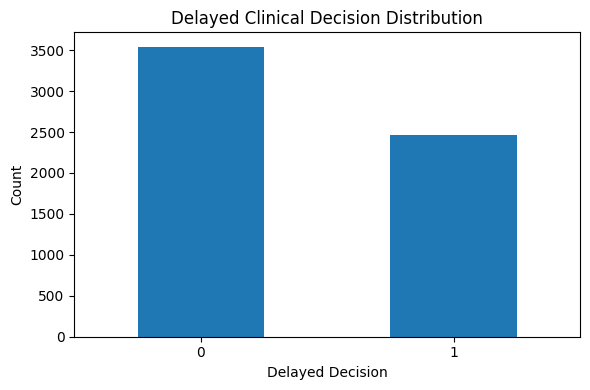

In [18]:
# Visualisation
plt.figure(figsize=(6, 4))
ed["delayed_decision"].value_counts().plot(kind="bar")
plt.title("Delayed Clinical Decision Distribution")
plt.xlabel("Delayed Decision")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

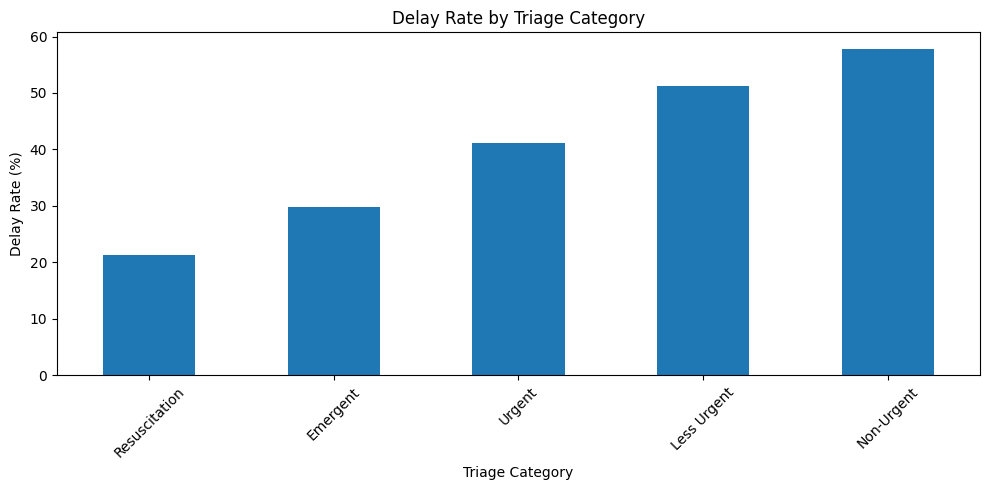

In [19]:
plt.figure(figsize=(10, 5))
delay_by_triage.sort_values("delay_rate").plot(
    x="triage_category",
    y="delay_rate",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)
plt.title("Delay Rate by Triage Category")
plt.xlabel("Triage Category")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

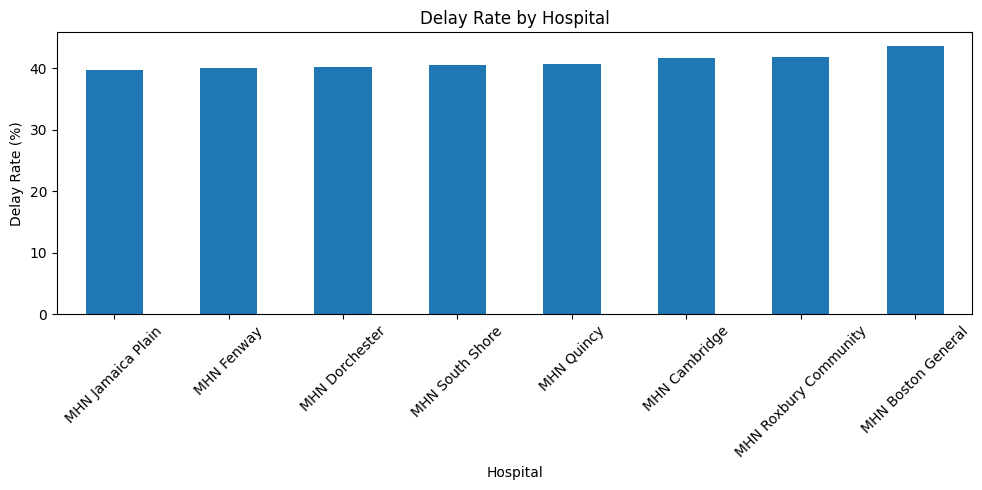

In [21]:
plt.figure(figsize=(10, 5))
delay_by_hospital.sort_values("delay_rate").plot(
    x="hospital",
    y="delay_rate",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)
plt.title("Delay Rate by Hospital")
plt.xlabel("Hospital")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

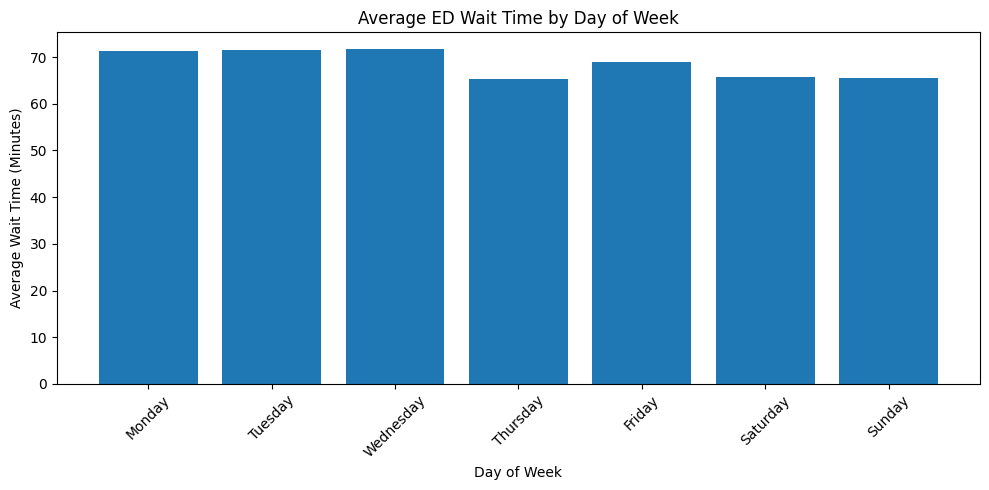

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    delay_by_day["day_of_week"],
    delay_by_day["avg_wait_time"]
)

plt.title("Average ED Wait Time by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Wait Time (Minutes)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
# Save investigation dataset

OUTPUT_FILE = BASE_DIR / "data" / "processed" / "delayed_decision_investigation.csv"
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

ed.to_csv(OUTPUT_FILE, index=False)

print("Saved:", OUTPUT_FILE)

Saved: c:\Users\lapto\OneDrive\Predictive Healthcare\Health-Care-predictive-Analysis\data\processed\delayed_decision_investigation.csv
